# Satellite Land Cover Classification

## Notebook 04 — Model Evaluation

In this notebook we evaluate the final machine learning model using the unseen test dataset.

### Objectives

- Load the saved train/test split
- Load the trained model
- Evaluate the model on unseen data
- Generate performance metrics
- Visualize the confusion matrix

In [5]:
from landcover import *

import pandas as pd

In [7]:
X_train, X_test, y_train, y_test = load_dataset_split()

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

Training Samples : 6,800
Testing Samples  : 1,700


In [8]:
model = load_model()

print("Model Loaded Successfully")

print()

print(model)

Model Loaded Successfully

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])


In [9]:
results = evaluate_model(
    model,
    X_test,
    y_test,
)

In [10]:
print(f"Test Accuracy : {results['accuracy']:.2%}")

Test Accuracy : 96.41%


In [11]:
results["classification_report"]

,precision,recall,f1-score,support
Forest,0.985149,0.995000,0.990050,600.000000
Residential,0.939394,0.981667,0.960065,600.000000
River,0.970021,0.906000,0.936918,500.000000
accuracy,0.964118,0.964118,0.964118,0.964118
macro avg,0.964855,0.960889,0.962344,1700.000000
weighted avg,0.964551,0.964118,0.963840,1700.000000


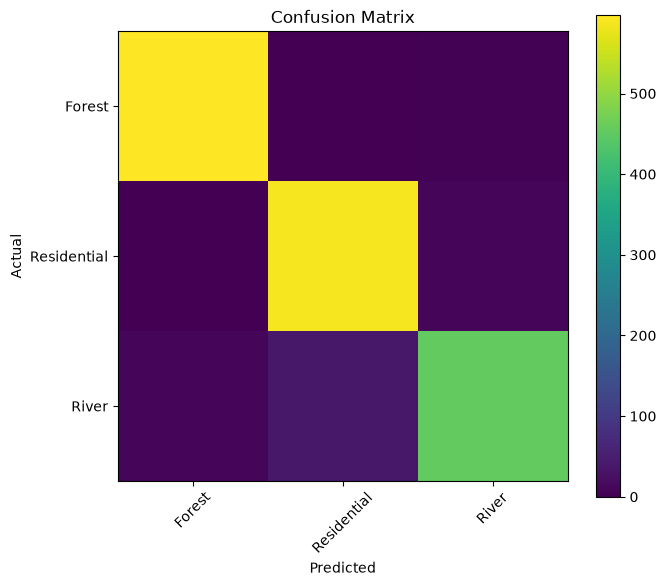

In [12]:
class_names = sorted(y_test.unique())

plot_confusion_matrix(
    results["confusion_matrix"],
    class_names,
)

In [13]:
predictions = pd.DataFrame({

    "Actual": y_test.reset_index(drop=True),

    "Predicted": results["predictions"]

})

display(predictions.head(20))

,Actual,Predicted
0,Residential,Residential
1,River,Residential
2,Forest,Forest
3,Forest,Forest
4,Residential,Residential
5,Forest,Forest
6,Forest,Forest
7,Forest,Forest
8,Forest,Forest
9,Residential,Residential


In [14]:
correct = (
    predictions["Actual"] ==
    predictions["Predicted"]
).sum()

incorrect = len(predictions) - correct

print(f"Correct Predictions   : {correct}")

print(f"Incorrect Predictions : {incorrect}")

Correct Predictions   : 1639
Incorrect Predictions : 61


In [15]:
print("=" * 60)

print("MODEL EVALUATION COMPLETE")

print("=" * 60)

print(f"Test Accuracy : {results['accuracy']:.2%}")

print()

print("The final model was evaluated")

print("using a completely unseen test dataset.")

print("=" * 60)

MODEL EVALUATION COMPLETE
Test Accuracy : 96.41%

The final model was evaluated
using a completely unseen test dataset.


In [16]:
predictions = X_test.copy()

predictions["Actual"] = y_test.values

predictions["Predicted"] = results["predictions"]

display(predictions.head())

,Mean_R,Mean_G,Mean_B,Std_R,Std_G,Std_B,Brightness,Actual,Predicted
0,77.892334,92.234131,100.041260,20.395034,15.968570,15.324900,90.055908,Residential,Residential
1,71.383057,87.304199,101.120361,24.596132,16.275018,15.466916,86.602539,River,Residential
2,36.306641,61.184326,72.972900,3.126830,3.919908,2.500781,56.821289,Forest,Forest
3,34.141602,59.802002,68.073730,4.857085,4.714983,3.139098,54.005778,Forest,Forest
4,109.327881,109.031738,125.452393,31.625844,27.652983,26.085163,114.604004,Residential,Residential


In [17]:
misclassified = predictions[
    predictions["Actual"] != predictions["Predicted"]
]

print(f"Misclassified Samples : {len(misclassified)}")

display(misclassified.head(10))

Misclassified Samples : 61


,Mean_R,Mean_G,Mean_B,Std_R,Std_G,Std_B,Brightness,Actual,Predicted
1,71.383057,87.304199,101.120361,24.596132,16.275018,15.466916,86.602539,River,Residential
15,81.888184,100.730713,108.464355,29.236412,19.956618,18.891683,97.027751,River,Residential
24,77.288086,86.305420,104.614258,22.115144,14.566581,10.971872,89.402588,River,Residential
102,55.462402,80.849121,87.226074,19.446379,13.125714,12.548778,74.512533,River,Residential
133,130.307861,132.728027,134.658691,26.774106,20.954069,18.165370,132.564860,River,Residential
141,74.375000,91.228027,103.843750,24.781417,17.920036,17.094778,89.815592,River,Residential
208,96.504639,107.241699,108.744629,29.499098,20.891032,17.835326,104.163656,River,Residential
249,80.026123,101.411865,109.238037,20.868989,15.295687,12.153447,96.892008,River,Residential
285,53.295654,80.198242,88.156982,22.180121,17.954961,17.518267,73.883626,River,Residential
301,49.892334,65.662109,77.909424,12.528517,9.866793,5.730295,64.487956,River,Forest


In [18]:
confusions = (
    misclassified
    .groupby(["Actual", "Predicted"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(confusions)

,Actual,Predicted,Count
3,River,Residential,38
1,Residential,River,11
2,River,Forest,9
0,Forest,River,3


## Observations

- Overall test accuracy exceeded **96%**.
- K-Nearest Neighbors produced the highest cross-validation performance.
- Most errors occurred between visually similar land cover classes.
- The confusion matrix indicates strong overall class separation with only a small number of misclassifications.